# AGILE Baseline Analysis — Brief 2

**Independent M&E review of Nigeria's Adolescent Girls Initiative for Learning and Empowerment (AGILE).**

- **Author:** Usman Almuarif Mashood
- **Data:** AGILE-IE Baseline Survey 2023 (`NGA_2023_AGILE-IE_v01_M`), World Bank Microdata Library — public-use, anonymised.
- **Sample:** 8,223 adolescent girls · 8,007 caregivers · 270 schools.
- **Geographic coverage:** Kaduna · Kano · Katsina (Senior Secondary 1, three of seven original AGILE states).
- **Outputs:** four publication-quality charts saved to `/content/brief2_analysis/charts/`, plus a CSV of key numbers for the brief's data appendix.

## How to use this notebook

1. Run **Cell 1** to install/import libraries.
2. Run **Cell 2** to upload the three CSVs (`adolescent_survey_anon.csv`, `caregiver_survey_anon.csv`, `school_survey_anon.csv`).
3. Run **Cell 3** to load and verify the data.
4. Run **Cells 4–7** to generate the four analyses, one per chart.
5. Run **Cell 8** to export the key findings CSV.
6. Run **Cell 9** to download all outputs to your laptop as a zip.

---
## Cell 1 — Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Output folders
OUT_DIR   = '/content/brief2_analysis'
CHART_DIR = os.path.join(OUT_DIR, 'charts')
os.makedirs(CHART_DIR, exist_ok=True)

# Colour palette — matches Brief 1 design
NAVY      = '#1a3a5c'
GOLD      = '#c89b3c'
TEAL      = '#3b7d7d'
GREY      = '#7a7a7a'
LIGHTGREY = '#e0e0e0'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#444444',
    'axes.titlepad': 14,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

STATE_MAP = {18: 'Kaduna', 19: 'Kano', 20: 'Katsina'}
print('Setup complete.')

Setup complete.


---
## Cell 2 — Upload the three CSV files

**This is the file-upload step.** When you run the cell, a chooser button appears in Colab. Click it and select **all three CSVs at once** (Ctrl-click or Cmd-click to multi-select). They are uploaded into the notebook's working memory at `/content/`.

Files needed:
- `adolescent_survey_anon.csv` (~36 MB)
- `caregiver_survey_anon.csv` (~17 MB)
- `school_survey_anon.csv` (~118 KB)

Total upload ~53 MB — takes 1–3 minutes depending on your connection. Once uploaded, the files live in `/content/` for as long as your Colab session stays connected.

In [2]:
from google.colab import files
uploaded = files.upload()

print('\nFiles uploaded to /content/:')
for name in uploaded.keys():
    size_mb = len(uploaded[name]) / 1e6
    print(f'  {name}  ({size_mb:.2f} MB)')

Saving adolescent_survey_anon.csv to adolescent_survey_anon.csv
Saving caregiver_survey_anon.csv to caregiver_survey_anon.csv
Saving school_survey_anon.csv to school_survey_anon.csv

Files uploaded to /content/:
  adolescent_survey_anon.csv  (35.81 MB)
  caregiver_survey_anon.csv  (16.83 MB)
  school_survey_anon.csv  (0.12 MB)


---
## Cell 3 — Load the three datasets and verify

We load each CSV with `latin-1` encoding (one of the files has a non-UTF-8 character). Then we confirm the row/column counts match the published metadata.

In [3]:
ad = pd.read_csv('/content/adolescent_survey_anon.csv', low_memory=False, encoding='latin-1')
cg = pd.read_csv('/content/caregiver_survey_anon.csv',  low_memory=False, encoding='latin-1')
sc = pd.read_csv('/content/school_survey_anon.csv',     low_memory=False, encoding='latin-1')

# Add a readable state name column to each
for df in (ad, cg, sc):
    df['state_name'] = df['state'].map(STATE_MAP)

print(f'Adolescent: {len(ad):>5,} rows × {ad.shape[1]:>4} cols   (expected 8,223 × 897)')
print(f'Caregiver:  {len(cg):>5,} rows × {cg.shape[1]:>4} cols   (expected 8,007 × 328)')
print(f'School:     {len(sc):>5,} rows × {sc.shape[1]:>4} cols   (expected   270 × 51)')

print('\nState distribution (adolescent file):')
print(ad['state_name'].value_counts())

Adolescent: 8,223 rows ×  898 cols   (expected 8,223 × 897)
Caregiver:  8,007 rows ×  329 cols   (expected 8,007 × 328)
School:       270 rows ×   52 cols   (expected   270 × 51)

State distribution (adolescent file):
state_name
Katsina    3345
Kano       2610
Kaduna     2268
Name: count, dtype: int64


---
## Cell 4 — Analysis 1: The Digital Literacy Floor

**Question:** What share of SS1 adolescent girls in the three AGILE states have ever used each digital device or service that AGILE's digital-literacy training intends to teach them?

**Why this matters for M&E:** AGILE counts *number of girls trained in digital literacy* as an output indicator, but it does not record the baseline digital exposure of those trainees. The same trained-count is recorded whether a girl was already familiar with a smartphone or had literally never touched any digital device.

**Output:** Chart `01_digital_literacy_floor.png`.

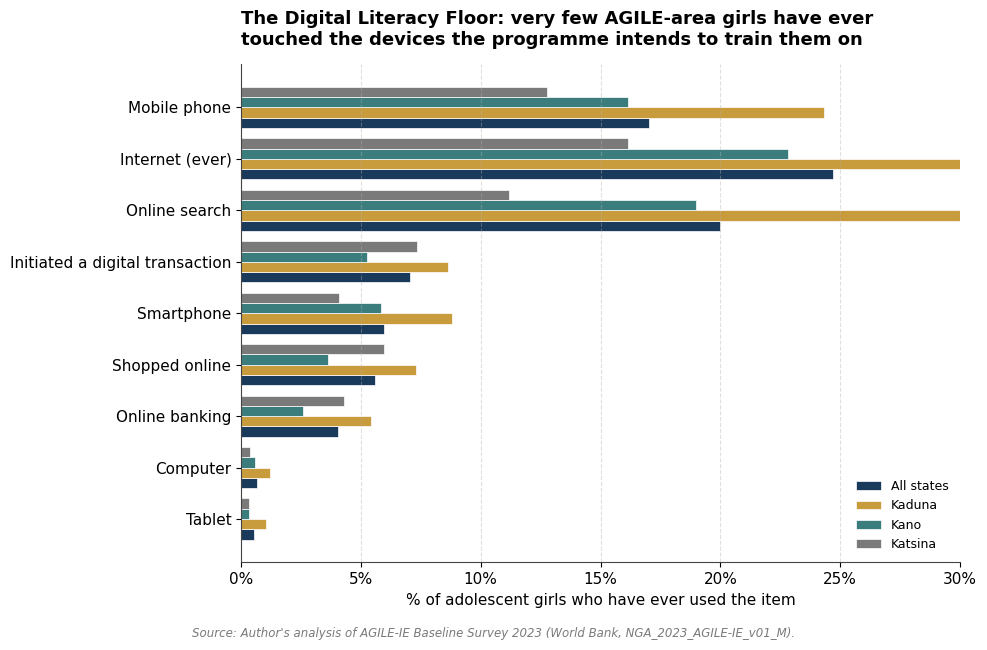


Saved: /content/brief2_analysis/charts/01_digital_literacy_floor.png


,item,state,pct
0,Mobile phone,Kaduna,24.338624
1,Mobile phone,Kano,16.130268
2,Mobile phone,Katsina,12.765321
3,Mobile phone,All states,17.025417
4,Internet (ever),Kaduna,39.417989
5,Internet (ever),Kano,22.835249
6,Internet (ever),Katsina,16.143498
7,Internet (ever),All states,24.686854
8,Online search,Kaduna,34.038801
9,Online search,Kano,19.003831


In [4]:
def add_source_caption(fig):
    fig.text(0.5, 0.01,
             "Source: Author's analysis of AGILE-IE Baseline Survey 2023 "
             '(World Bank, NGA_2023_AGILE-IE_v01_M).',
             ha='center', fontsize=8.5, color=GREY, style='italic')

items = [
    ('dl3_2_mobilephone',     'Mobile phone'),
    ('dl3_1_internet',        'Internet (ever)'),
    ('dl3_6_online_search',   'Online search'),
    ('dl3_27_initiat_transac','Initiated a digital transaction'),
    ('dl3_3_smartphone',      'Smartphone'),
    ('dl3_21_shoponline',     'Shopped online'),
    ('dl3_23_online_bankin',  'Online banking'),
    ('dl3_4_computer',        'Computer'),
    ('dl3_5_tabletcomputer',  'Tablet'),
]

rows = []
for col, label in items:
    for state_code, state_name in STATE_MAP.items():
        pct = 100.0 * ad[ad['state'] == state_code][col].mean()
        rows.append({'item': label, 'state': state_name, 'pct': pct})
    rows.append({'item': label, 'state': 'All states', 'pct': 100.0 * ad[col].mean()})
df1 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 6.5))
item_order  = [lab for _, lab in items]
state_order = ['All states', 'Kaduna', 'Kano', 'Katsina']
bar_h = 0.20
y_positions = np.arange(len(item_order))
colors = {'All states': NAVY, 'Kaduna': GOLD, 'Kano': TEAL, 'Katsina': GREY}

for i, st in enumerate(state_order):
    vals = [df1[(df1['item'] == lab) & (df1['state'] == st)]['pct'].iloc[0]
            for lab in item_order]
    ax.barh(y_positions + (1.5 - i) * bar_h, vals, height=bar_h,
            color=colors[st], label=st, edgecolor='white', linewidth=0.5)

ax.set_yticks(y_positions); ax.set_yticklabels(item_order); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 30)
ax.set_xlabel('% of adolescent girls who have ever used the item')
ax.set_title('The Digital Literacy Floor: very few AGILE-area girls have ever\n'
             'touched the devices the programme intends to train them on', loc='left')
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 1])
add_source_caption(fig)
out1 = os.path.join(CHART_DIR, '01_digital_literacy_floor.png')
plt.savefig(out1, dpi=180, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out1}')
df1

---
## Cell 5 — Analysis 2: The Caregiver Aspiration Gradient

**Question:** What level of educational attainment do caregivers expect for the adolescent in their household, and does that expectation vary across the three AGILE states?

**Why this matters for M&E:** AGILE's Component 2 invests in social-norm change to raise expectations for girls' education. But the official Results Framework does not track caregiver aspiration as an outcome indicator. Without that measurement, the most expensive social-norm interventions cannot demonstrate impact.

**Output:** Chart `02_caregiver_aspiration_gradient.png`.

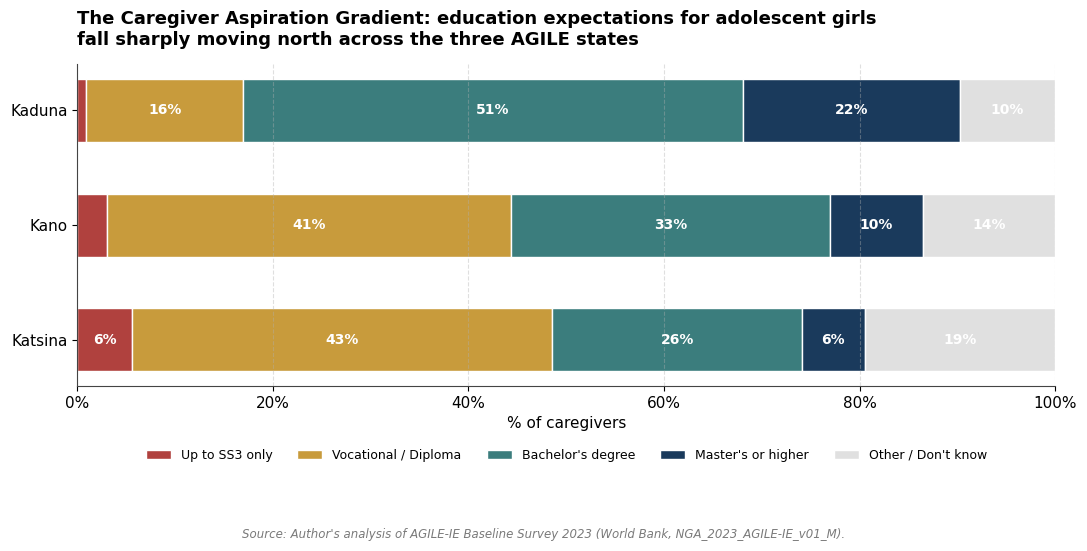


Saved: /content/brief2_analysis/charts/02_caregiver_aspiration_gradient.png


aspiration_label,None,Primary,Junior secondary,Senior secondary (SS3),Vocational/TVET,Diploma/NCE,Bachelor's degree,Master's,Doctorate,Other/Don't know
state_name,,,,,,,,,,
Kaduna,0.0,0.2,0.1,0.6,2.9,13.1,51.1,17.9,4.3,9.8
Kano,0.1,0.0,0.2,2.8,1.3,40.0,32.6,8.3,1.2,13.5
Katsina,0.5,0.0,0.3,4.9,1.1,41.9,25.5,4.5,1.9,19.5


In [5]:
asp_map = {
    1: 'None', 3: 'Primary', 4: 'Junior secondary', 5: 'Senior secondary (SS3)',
    6: 'Vocational/TVET', 7: 'Diploma/NCE', 8: "Bachelor's degree",
    9: "Master's", 10: 'Doctorate', 11: "Other/Don't know",
}
cg['aspiration_label'] = cg['aa2_3_lvl_constrnt_educ'].map(asp_map)
order = ['None', 'Primary', 'Junior secondary', 'Senior secondary (SS3)',
         'Vocational/TVET', 'Diploma/NCE', "Bachelor's degree",
         "Master's", 'Doctorate', "Other/Don't know"]

pivot = (cg.dropna(subset=['aspiration_label', 'state_name'])
           .groupby(['state_name', 'aspiration_label']).size()
           .unstack(fill_value=0))
pivot = pivot.reindex(columns=order, fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
state_order = ['Kaduna', 'Kano', 'Katsina']
y = np.arange(len(state_order))
cumulative = np.zeros(len(state_order))

bands = {
    'Up to SS3 only':       (['None', 'Primary', 'Junior secondary', 'Senior secondary (SS3)'], '#b0413e'),
    'Vocational / Diploma': (['Vocational/TVET', 'Diploma/NCE'],   GOLD),
    "Bachelor's degree":    (["Bachelor's degree"],                TEAL),
    "Master's or higher":   (["Master's", 'Doctorate'],             NAVY),
    "Other / Don't know":   (["Other/Don't know"],                  LIGHTGREY),
}

for band_label, (cats, color) in bands.items():
    vals = pivot_pct.loc[state_order, cats].sum(axis=1).values
    ax.barh(y, vals, left=cumulative, height=0.55,
            color=color, label=band_label, edgecolor='white', linewidth=1.0)
    for i, v in enumerate(vals):
        if v >= 4:
            ax.text(cumulative[i] + v/2, y[i], f'{v:.0f}%',
                    ha='center', va='center', color='white',
                    fontsize=10, fontweight='bold')
    cumulative += vals

ax.set_yticks(y); ax.set_yticklabels(state_order); ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlabel('% of caregivers')
ax.set_title('The Caregiver Aspiration Gradient: education expectations for adolescent girls\n'
             'fall sharply moving north across the three AGILE states', loc='left')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.27),
          ncol=5, frameon=False, fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.06, 1, 1])
add_source_caption(fig)
out2 = os.path.join(CHART_DIR, '02_caregiver_aspiration_gradient.png')
plt.savefig(out2, dpi=180, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out2}')
pivot_pct.round(1)

---
## Cell 6 — Analysis 3: Household Food Insecurity

**Question:** How widespread is food insecurity in the AGILE-IE sample, and when food runs short, who in the household goes without?

**Why this matters for M&E:** AGILE's Component 2 includes financial incentives explicitly targeted at the poorest households. The official Results Framework does not include any household-level food security indicator. Without that, the programme cannot verify whether the incentives reach the households for whom skipped meals are a recurring reality.

**Output:** Chart `03_food_insecurity.png`.

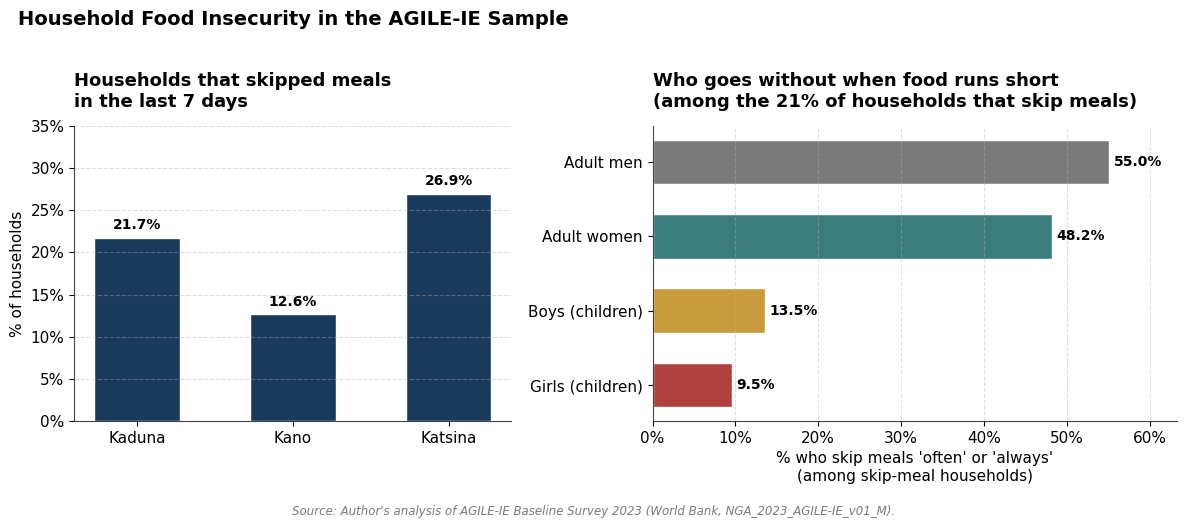


Saved: /content/brief2_analysis/charts/03_food_insecurity.png

Skipping by state:
state_name
Kaduna     21.7
Kano       12.6
Katsina    26.9
Name: fs_1_skip_meal, dtype: float64

Who goes without:
             member  often_or_always_pct
0         Adult men                 55.0
1       Adult women                 48.2
2   Boys (children)                 13.5
3  Girls (children)                  9.5


In [6]:
# Panel A: % of households reporting any meal-skipping, by state
skip = (cg.groupby('state_name')['fs_1_skip_meal']
          .mean().mul(100).reindex(['Kaduna', 'Kano', 'Katsina']))

# Panel B: among households that skip, frequency by household member type
# Codes: 1 = rarely, 2 = sometimes, 3 = often, 4 = always; -555 = N/A
sub = cg[cg['fs_1_skip_meal'] == 1].copy()
members = {
    'fs_3a_adultmen':   'Adult men',
    'fs_3b_adultwomen': 'Adult women',
    'fs_3c_boys':       'Boys (children)',
    'fs_3d_girls':      'Girls (children)',
}
rows = []
for col, label in members.items():
    s = sub[col].replace(-555, np.nan).dropna()
    if len(s) == 0:
        continue
    often_pct = 100.0 * s.isin([3, 4]).mean()
    rows.append({'member': label, 'often_or_always_pct': often_pct})
freq_df = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                               gridspec_kw={'width_ratios': [1, 1.2]})

# Panel A
bars = ax1.bar(skip.index, skip.values, color=NAVY, width=0.55,
               edgecolor='white', linewidth=1.0)
ax1.set_ylim(0, 35)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax1.set_ylabel('% of households')
ax1.set_title('Households that skipped meals\nin the last 7 days', loc='left')
for b, v in zip(bars, skip.values):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.7, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Panel B
member_order = ['Adult men', 'Adult women', 'Boys (children)', 'Girls (children)']
freq_df = freq_df.set_index('member').reindex(member_order).reset_index()
colors_b = [GREY, TEAL, GOLD, '#b0413e']
bars2 = ax2.barh(freq_df['member'], freq_df['often_or_always_pct'],
                 color=colors_b, edgecolor='white', linewidth=1.0, height=0.6)
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.set_xlim(0, max(60, freq_df['often_or_always_pct'].max() * 1.15))
ax2.set_xlabel("% who skip meals 'often' or 'always'\n(among skip-meal households)")
ax2.set_title('Who goes without when food runs short\n'
              '(among the 21% of households that skip meals)', loc='left')
for b, v in zip(bars2, freq_df['often_or_always_pct']):
    ax2.text(v + 0.6, b.get_y() + b.get_height()/2, f'{v:.1f}%',
             ha='left', va='center', fontsize=10, fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.4)

fig.suptitle('Household Food Insecurity in the AGILE-IE Sample',
             fontsize=14, fontweight='bold', y=1.02, x=0.02, ha='left')
plt.tight_layout(rect=[0, 0.04, 1, 1])
add_source_caption(fig)
out3 = os.path.join(CHART_DIR, '03_food_insecurity.png')
plt.savefig(out3, dpi=180, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out3}')
print('\nSkipping by state:'); print(skip.round(1))
print('\nWho goes without:'); print(freq_df.round(1))

---
## Cell 7 — Analysis 4: School Infrastructure Reality Check

**Question:** What share of AGILE-area SS1 schools meet basic facility standards at programme baseline?

**Why this matters for M&E:** AGILE Component 1 invests heavily in school infrastructure. The Results Framework tracks construction outputs (classrooms built, toilets installed). But the baseline shows that the binding constraint in the existing stock is not absence of facilities — most schools have toilets, water, and blackboards — but capacity: only 26% of schools have sufficient classroom seats for SS1 students. Construction without seating addresses the wrong gap.

**Output:** Chart `04_school_infrastructure.png`.

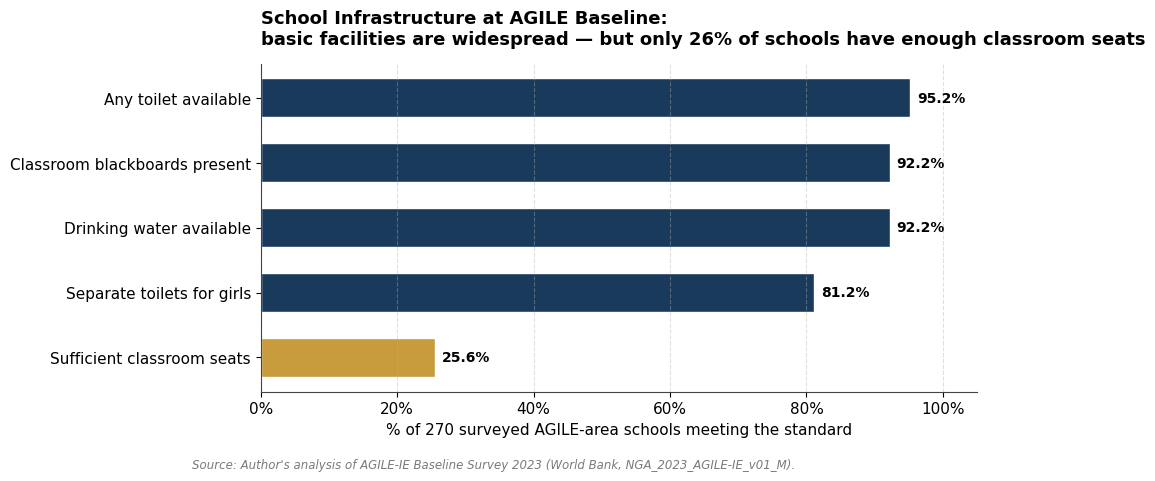


Saved: /content/brief2_analysis/charts/04_school_infrastructure.png


,item,pct_yes,n
4,Sufficient classroom seats,25.6,270
3,Separate toilets for girls,81.2,260
1,Drinking water available,92.2,270
0,Classroom blackboards present,92.2,270
2,Any toilet available,95.2,270


In [7]:
items_sc = [
    ('if_12_class_blckboard', 'Classroom blackboards present'),
    ('if_14_drinkng_water',   'Drinking water available'),
    ('if_16_toilet',          'Any toilet available'),
    ('if_17_separate_toilet', 'Separate toilets for girls'),
    ('if_13_class_seats',     'Sufficient classroom seats'),
]
rows = []
for col, label in items_sc:
    rows.append({
        'item': label,
        'pct_yes': 100.0 * sc[col].mean(skipna=True),
        'n': sc[col].notna().sum(),
    })
df4 = pd.DataFrame(rows).sort_values('pct_yes', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4.8))
colors_b = [GOLD if v < 50 else NAVY for v in df4['pct_yes']]
bars = ax.barh(df4['item'], df4['pct_yes'], color=colors_b,
               edgecolor='white', linewidth=1.0, height=0.6)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 105)
ax.set_xlabel('% of 270 surveyed AGILE-area schools meeting the standard')
ax.set_title('School Infrastructure at AGILE Baseline:\n'
             'basic facilities are widespread — but only 26% of schools have enough classroom seats',
             loc='left')
for b, v in zip(bars, df4['pct_yes']):
    ax.text(v + 1.0, b.get_y() + b.get_height()/2, f'{v:.1f}%',
            ha='left', va='center', fontsize=10, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.04, 1, 1])
add_source_caption(fig)
out4 = os.path.join(CHART_DIR, '04_school_infrastructure.png')
plt.savefig(out4, dpi=180, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out4}')
df4.round(1)

---
## Cell 8 — Export key findings to a CSV for the brief's data appendix

In [8]:
rows = []
for _, r in df1.iterrows():
    rows.append({'analysis': '1_digital', 'state': r['state'],
                 'item': r['item'], 'value_pct': round(r['pct'], 2)})
for state in pivot_pct.index:
    for level in pivot_pct.columns:
        rows.append({'analysis': '2_aspiration', 'state': state,
                     'item': level, 'value_pct': round(pivot_pct.loc[state, level], 2)})
for state, v in skip.items():
    rows.append({'analysis': '3_skip_by_state', 'state': state,
                 'item': 'Any meal skipped (past 7 days)',
                 'value_pct': round(v, 2)})
for _, r in freq_df.iterrows():
    rows.append({'analysis': '3_skip_by_member', 'state': 'All',
                 'item': r['member'],
                 'value_pct': round(r['often_or_always_pct'], 2)})
for _, r in df4.iterrows():
    rows.append({'analysis': '4_infra', 'state': 'All',
                 'item': r['item'], 'value_pct': round(r['pct_yes'], 2)})

out_csv = os.path.join(OUT_DIR, 'key_findings_numbers.csv')
pd.DataFrame(rows).to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
pd.DataFrame(rows).head(20)

Saved: /content/brief2_analysis/key_findings_numbers.csv


,analysis,state,item,value_pct
0,1_digital,Kaduna,Mobile phone,24.34
1,1_digital,Kano,Mobile phone,16.13
2,1_digital,Katsina,Mobile phone,12.77
3,1_digital,All states,Mobile phone,17.03
4,1_digital,Kaduna,Internet (ever),39.42
5,1_digital,Kano,Internet (ever),22.84
6,1_digital,Katsina,Internet (ever),16.14
7,1_digital,All states,Internet (ever),24.69
8,1_digital,Kaduna,Online search,34.04
9,1_digital,Kano,Online search,19.00


---
## Cell 9 — Zip everything and download to your laptop

Bundles the four PNGs and the CSV into a single zip you can drop into your GitHub repo or attach to your brief.

In [9]:
import shutil
from google.colab import files

zip_base = '/content/agile_brief2_outputs'
shutil.make_archive(zip_base, 'zip', OUT_DIR)
files.download(zip_base + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>